Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
S2N17 — peak1: η=169.77°, κ=310.15°, value=108.264
S2N17 — peak2: η=10.23°, κ=130.15°, value=108.264
S2N18 — peak1: η=85.08°, κ=266.08°, value=101.296
S2N18 — peak2: η=94.92°, κ=86.08°, value=101.296
S4N06 — peak1: η=110.27°, κ=270.25°, value=118.557
S4N06 — peak2: η=69.73°, κ=90.25°, value=118.557
S4N11 — peak1: η=110.61°, κ=89.35°, value=101.079
S4N11 — peak2: η=69.39°, κ=269.35°, value=101.079
S4N25 — peak1: η=56.84°, κ=269.82°, value=100.265
S4N25 — peak2: η=123.16°, κ=89.81°, value=100.265
S6N08 — peak1: η=79.69°, κ=90.93°, value=66.4887
S6N08 — peak2: η=100.31°, κ=270.93°, value=66.4887


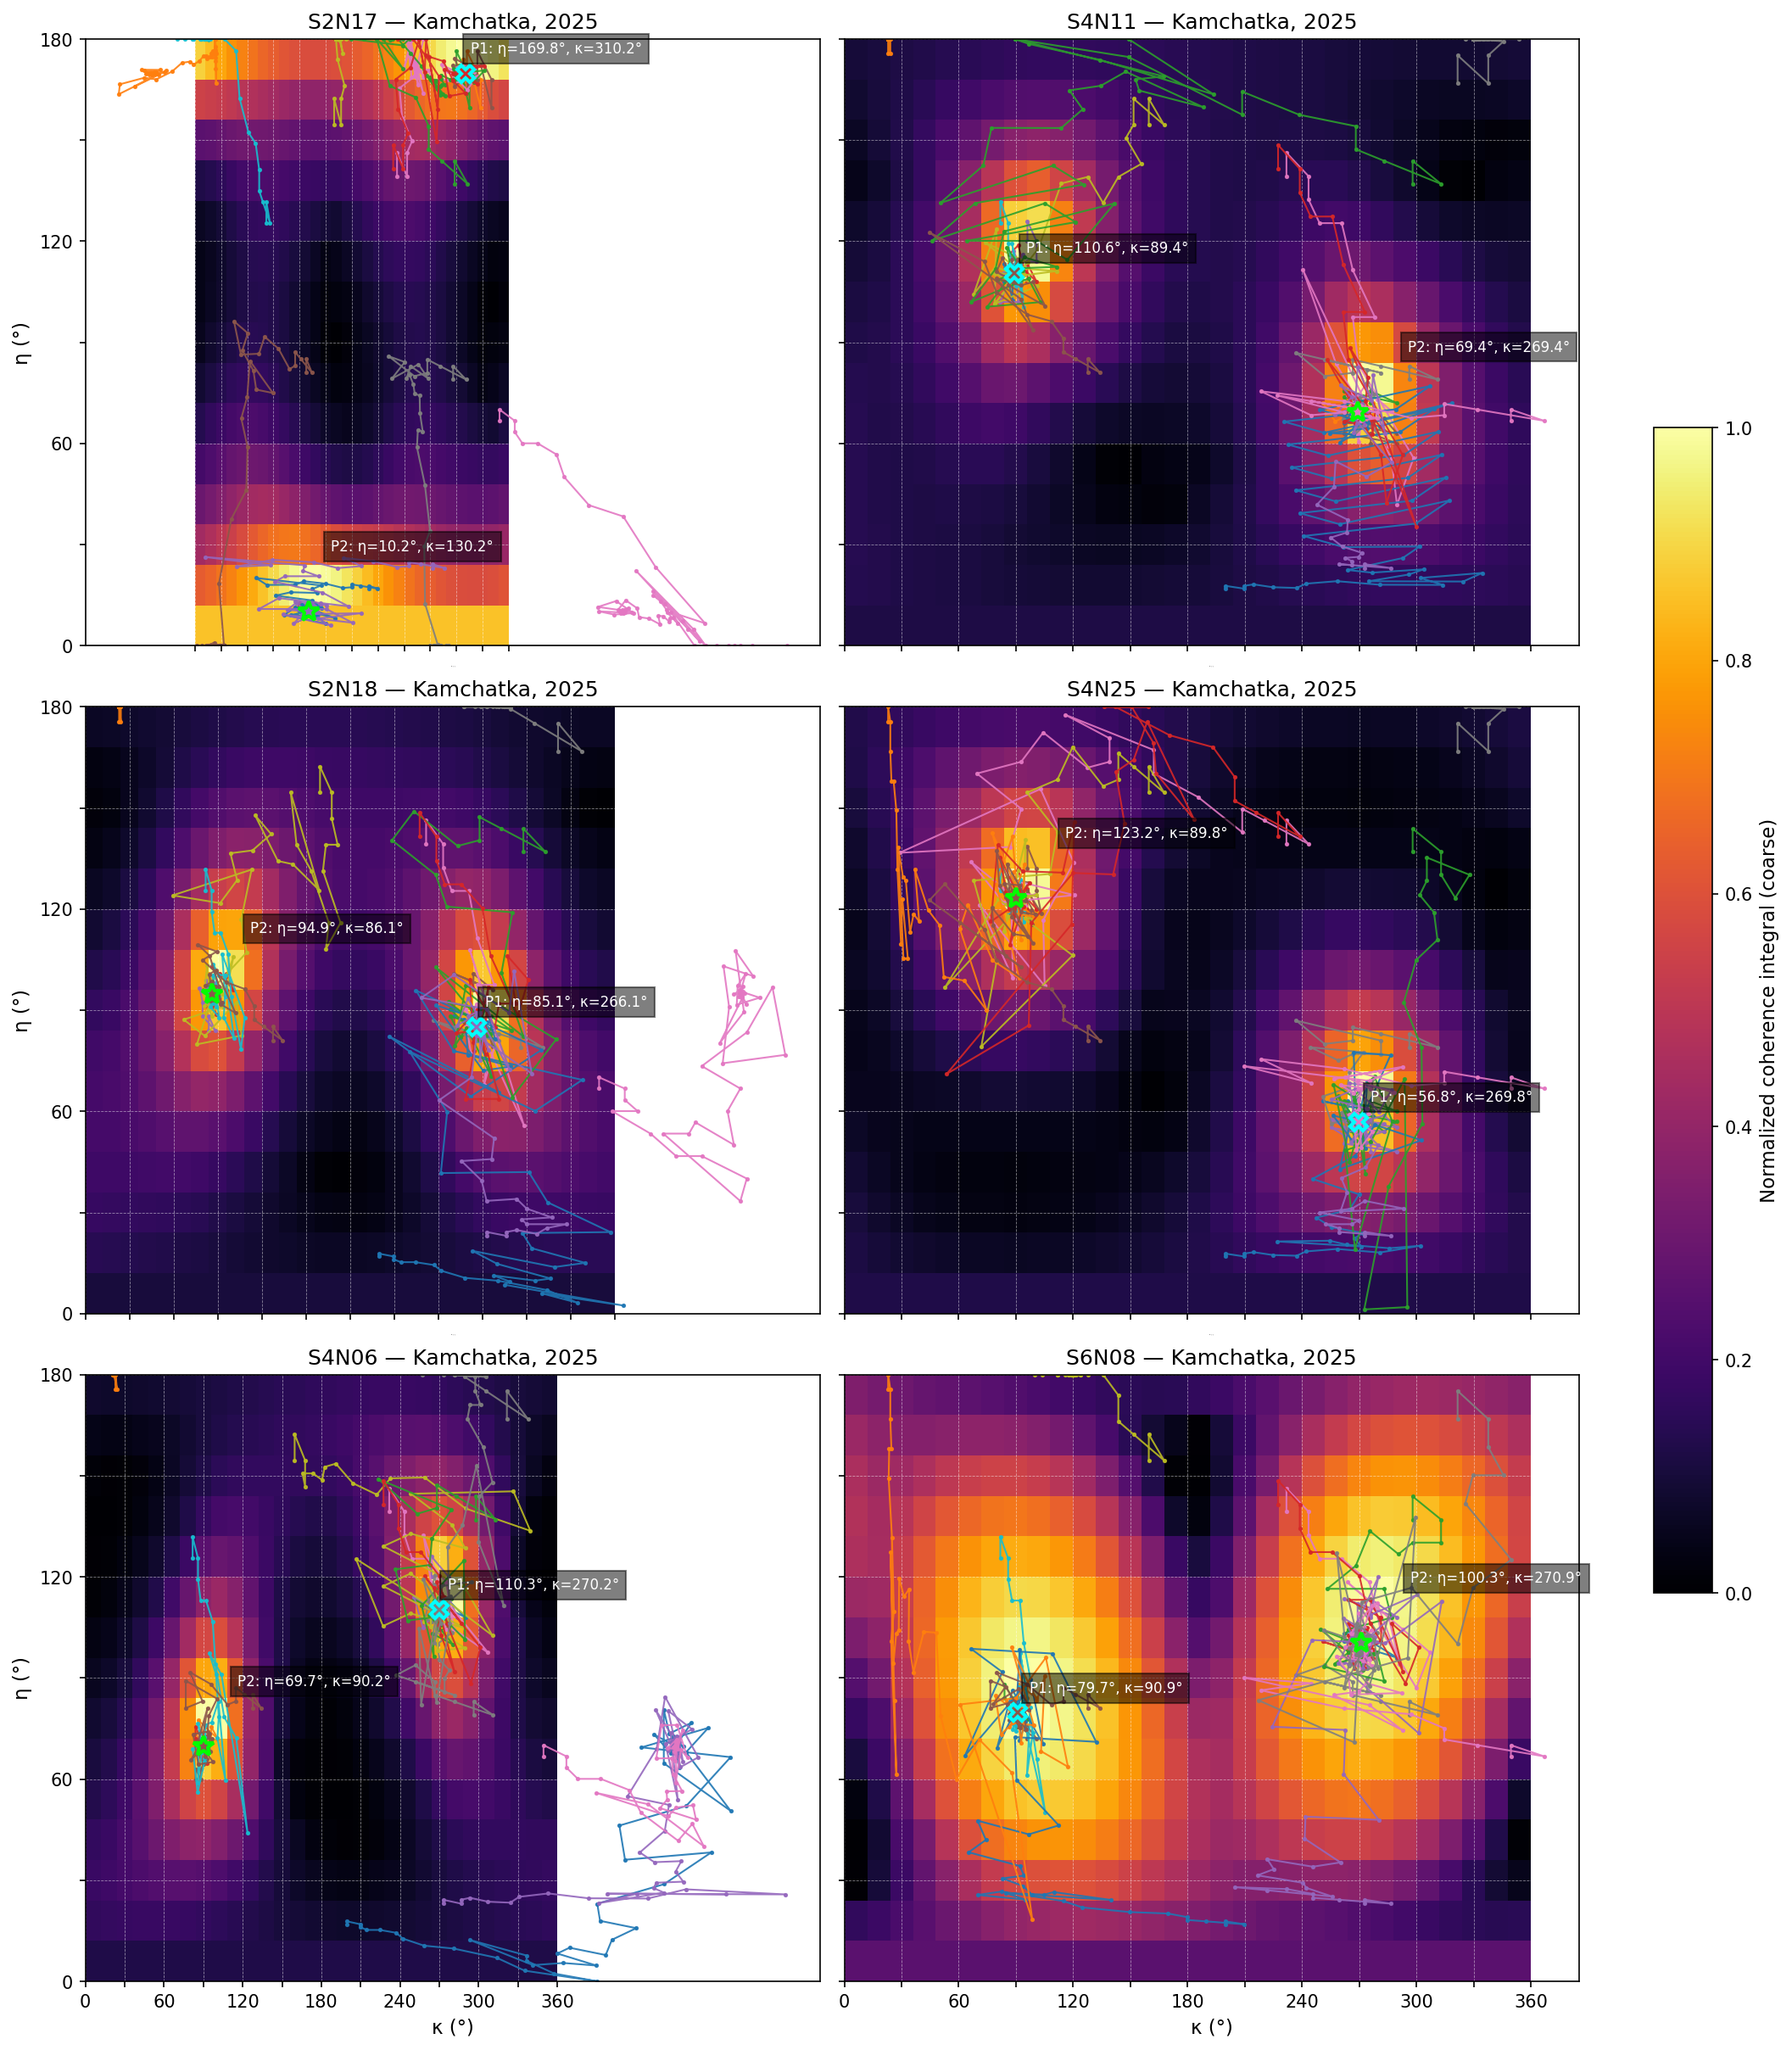

Time: 183.93 sec.
Saved: event2_coarse_opt_trajs.png

Top-2 peaks for each station:
station   eta1_deg  kappa1_deg     value1   eta2_deg  kappa2_deg     value2
  S2N17 169.772915  310.150475 108.264433  10.227385  130.150575 108.264433
  S2N18  85.083224  266.080790 101.295983  94.915790   86.080307 101.295983
  S4N06 110.268492  270.246927 118.556940  69.731418   90.246987 118.556940
  S4N11 110.610906   89.350437 101.078971  69.389183  269.350549 101.078971
  S4N25  56.842814  269.815017 100.265459 123.157079   89.814814 100.265459
  S6N08  79.693564   90.925851  66.488660 100.306278  270.925678  66.488660


In [2]:
import time

from google.colab import drive
drive.mount('/content/drive')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import math
from scipy.optimize import minimize
start_time = time.time()
# -----------------------

nperseg = 2**13
samplelen = 71999

# coarse / meta-parameters of optimization
coarse_theta_n = 15          # coarse eta grid (0..180)
coarse_phi_n = 30           # coarse kappa grid (0..360)
num_starts = 6              # how many best points from coarse grid to use as starting points (from coarse)
init_random_starts = 12     # how many random starts to add immediately (new)
seed = 42                   # seed for reproducibility of random starts
max_total_starts = 30       # maximum starts (coarse + random) to avoid overload
local_maxiter = 800         # max iterations for Nelder-Mead
unique_tol_deg = 3.0        # difference between peaks/starts to be considered unique (deg)
extra_random_starts = 12    # additional random starts if needed (later)
refine_half_span = 1.0      # degrees for final grid refinement
refine_steps = 11           # steps for refinement
# -----------------------

stations = [
    [r'\S2N17', 'e30e', 'e302', '2247', '0.04893', '0.04792', '0.04923', 'e300', 'e301'],
    [r'\S2N18', 'e31e', 'e312', '2460', '0.04878', '0.04930', '0.04885', 'e310', 'e311'],
    [r'\S4N06', 'e65c', 'e652', '1970', '0.04874', '0.04863', '0.04856', 'e650', 'e651'],
    [r'\S4N11', 'e6ae', 'e6a2', '2273', '0.04829', '0.04818', '0.04912', 'e6a0', 'e6a1'],
    [r'\S4N25', 'e78e', 'e782', '2228', '0.04792', '0.04811', '0.04729', 'e780', 'e781'],
    [r'\S6N08', 'ea7e', 'ea72', '5900', '0.05205', '0.05182', '0.05178', 'ea70', 'ea71'],
]

eventsp = [
    r'/content/drive/MyDrive/data/pressure/Noto/',
    r'/content/drive/MyDrive/data/pressure/Gulf/',
    r'/content/drive/MyDrive/data/pressure/Kamchatka/',
    r'/content/drive/MyDrive/data/pressure/Chignik/'
]
eventsac = [
    r'/content/drive/MyDrive/data/acceleration/Noto/',
    r'/content/drive/MyDrive/data/acceleration/Gulf/',
    r'/content/drive/MyDrive/data/acceleration/Kamchatka/',
    r'/content/drive/MyDrive/data/acceleration/Chignik/'
]

event_index = 2
event_title_map = {0: 'Noto, 2024', 1: 'Gulf of Alaska, 2018', 2: 'Kamchatka, 2025'}
event_title = event_title_map.get(event_index, f'Event {event_index}')

b_list = []
station_names = []
valid_indices = []

# full fine grids (only for compatibility/labels)
thetres = 180
phires = 360
th = np.linspace(0, 180, thetres)
ph = np.linspace(0, 360, phires)

# For storing top-2 peaks: dict station -> list of tuples (eta_deg, kappa_deg, value)
top_peaks = {}
# For visualization: trajectories: dict station -> list of trajs (each traj is list of (eta,kappa))
traj_map = {}

# ---- helper functions ----
def periodic_dist(a, b, period):
    d = abs(a - b) % period
    return min(d, period - d)

def is_unique_peak(new_eta, new_kappa, found_peaks, tol_deg=unique_tol_deg):
    """Uniqueness: cyclic for kappa, but NOT for eta (eta is simple absolute difference)."""
    for (e, k, v) in found_peaks:
        if periodic_dist(new_kappa, k, 360.0) <= tol_deg and abs(new_eta - e) <= tol_deg:
            return False
    return True

def start_is_unique(new_eta, new_kappa, start_list, tol_deg=unique_tol_deg):
    """Similar uniqueness, but for starting points (to avoid duplicate starts)."""
    for (e, k) in start_list:
        if periodic_dist(new_kappa, k, 360.0) <= tol_deg and abs(new_eta - e) <= tol_deg:
            return False
    return True

# ---- main loop over stations ----
for idx, st in enumerate(stations):
    station_name = st[0][1:]
    station_names.append(station_name)

    pres_path = eventsp[event_index] + st[1] + '.dat'
    acc_vert_path = eventsac[event_index] + st[2] + '.dat'
    acc_x_path = eventsac[event_index] + st[7] + '.dat'
    acc_y_path = eventsac[event_index] + st[8] + '.dat'

    if not (os.path.exists(pres_path) and os.path.exists(acc_vert_path) and os.path.exists(acc_x_path) and os.path.exists(acc_y_path)):
        print(f"Warning: skipping station {station_name} (some files not found).")
        b_list.append(None)
        top_peaks[station_name] = [(float(th[0]), float(ph[0]), 0.0)]
        traj_map[station_name] = []
        continue

    try:
        data = pd.read_csv(pres_path, delimiter='\t') / 14.0
        data2 = pd.read_csv(acc_vert_path, delimiter='\t') / float(st[4]) * 4.377e-7
        datax = pd.read_csv(acc_x_path, delimiter='\t') / float(st[5]) * 4.377e-7
        datay = pd.read_csv(acc_y_path, delimiter='\t') / float(st[6]) * 4.377e-7
    except Exception as e:
        print(f"Error reading files for {station_name}: {e}")
        b_list.append(None)
        top_peaks[station_name] = [(float(th[0]), float(ph[0]), 0.0)]
        traj_map[station_name] = []
        continue

    # resample/detrend and trim (as you had)
    data2 = signal.resample(data2, (len(data2)+1)//10 - 1)
    data2 = signal.detrend(data2, axis=0)
    datax = signal.resample(datax, (len(datax)+1)//10 - 1)
    datax = signal.detrend(datax, axis=0)
    datay = signal.resample(datay, (len(datay)+1)//10 - 1)
    datay = signal.detrend(datay, axis=0)

    data2 = np.asarray(data2).flatten()[17500:samplelen].copy()
    datax = np.asarray(datax).flatten()[17500:samplelen].copy()
    datay = np.asarray(datay).flatten()[17500:samplelen].copy()

    x = np.linspace(0, len(data), num=len(data)+1)[:-1]
    data = data[17500:samplelen].copy()
    x = x[17500:samplelen].copy()

    model = np.polyfit(x, data.to_numpy().flatten(), 8)
    predicted = np.polyval(model, x)
    data_arr = data.T.to_numpy()[0]
    data_arr = data_arr - predicted
    data_arr = np.asarray(data_arr).flatten()

    # --- cache and variable setup locally for station ---
    eval_cache = {}  # cache: key -> integral (key = (eta*1000, kappa*1000) int)
    trajectories = []  # list of point lists (eta,kappa) for each starting optimizer

    def eval_integral(eta_deg, kappa_deg):
        """Compute coherence integral. Uses local cache.
           !! eta is NOT cyclic: constrain it to [0,180]. kappa is cyclic (mod 360)."""
        # don't wrap eta modulo — just constrain:
        eta = float(eta_deg)
        eta = min(max(eta, 0.0), 180.0)  # !! non-cyclic for eta
        kappa = float(kappa_deg) % 360.0
        key = (int(round(eta * 1000)), int(round(kappa * 1000)))
        if key in eval_cache:
            return eval_cache[key]

        cos_t = math.cos(math.radians(eta))
        sin_t = math.sin(math.radians(eta))
        phi_rad = math.radians(kappa)

        truez = (data2 * cos_t +
                 datay * sin_t * math.sin(phi_rad) +
                 datax * sin_t * math.cos(phi_rad))
        try:
            xwelch, welch = signal.coherence(data_arr, truez, fs=10, nperseg=nperseg, axis=0)
        except Exception:
            xwelch = np.array([0.])
            welch = np.array([0.])

        fmin = 0.366 * math.sqrt(9.8 / float(st[3]))
        fmax = max(0.1, 1500.0 / (4.0 * float(st[3])))
        mask = (xwelch > fmin) & (xwelch < fmax)
        integral = float(np.sum(np.abs(welch[mask])))
        eval_cache[key] = integral
        return integral

    # --- building the coarse map ---
    th_coarse = np.linspace(0.0, 180.0, coarse_theta_n, endpoint=False)
    ph_coarse = np.linspace(0.0, 360.0, coarse_phi_n, endpoint=False)
    b_coarse = np.zeros((len(th_coarse), len(ph_coarse)))
    for i, theta in enumerate(th_coarse):
        for j, phi in enumerate(ph_coarse):
            b_coarse[i, j] = eval_integral(theta, phi)

    # Best starting points from coarse grid
    flat_idx = np.argpartition(b_coarse.flatten(), -num_starts)[-num_starts:]
    sorted_idx = flat_idx[np.argsort(b_coarse.flatten()[flat_idx])[::-1]]
    start_points = []
    for flat in sorted_idx:
        i0, j0 = np.unravel_index(flat, b_coarse.shape)
        start_points.append((float(th_coarse[i0]), float(ph_coarse[j0])))

    # --- add random starts immediately (with duplicate filtering) ---
    rng = np.random.default_rng(seed)
    rand_thetas = rng.uniform(0, 180, size=init_random_starts)
    rand_phis = rng.uniform(0, 360, size=init_random_starts)
    for rt, rp in zip(rand_thetas, rand_phis):
        if len(start_points) >= max_total_starts:
            break
        if start_is_unique(rt, rp, start_points, tol_deg=unique_tol_deg):
            start_points.append((float(rt), float(rp)))

    # (optional) limit total number of starts
    if len(start_points) > max_total_starts:
        start_points = start_points[:max_total_starts]

    # --- local optimization (multi-start) with trajectory recording ---
    found_peaks = []  # (eta,kappa,value)

    # closure for recording optimizer trajectories
    def make_neg_obj(traj_list):
        def neg_obj(x):
            # save evaluations (for visualizing optimization path)
            # !! DO NOT use %180 for eta — just constrain when recording
            eta = float(x[0])
            eta = min(max(eta, 0.0), 180.0)  # !! non-cyclic eta
            kappa = float(x[1]) % 360.0
            traj_list.append((eta, kappa))
            return -eval_integral(eta, kappa)
        return neg_obj

    # run local optimization from all starting points (coarse + random)
    for (eta0, kappa0) in start_points:
        traj = []
        neg_obj = make_neg_obj(traj)
        x0 = np.array([eta0, kappa0], dtype=float)
        res = minimize(neg_obj, x0, method='Nelder-Mead',
                       options={'maxiter': local_maxiter, 'xatol': 1e-3, 'fatol': 1e-6, 'disp': False})
        # no modulo for eta — just constrain:
        eta_opt = float(res.x[0])
        eta_opt = min(max(eta_opt, 0.0), 180.0)  # !! non-cyclic
        kappa_opt = float(res.x[1] % 360.0)
        val_opt = eval_integral(eta_opt, kappa_opt)
        if val_opt <= 0:
            if not found_peaks:
                found_peaks.append((eta_opt, kappa_opt, val_opt))
        else:
            if is_unique_peak(eta_opt, kappa_opt, found_peaks, tol_deg=unique_tol_deg):
                found_peaks.append((eta_opt, kappa_opt, val_opt))
        trajectories.append(traj)

    # additional random starts if too few peaks (as before)
    if len(found_peaks) < 2:
        rng2 = np.random.default_rng(seed + 1)
        rand_thetas = rng2.uniform(0, 180, size=extra_random_starts)
        rand_phis = rng2.uniform(0, 360, size=extra_random_starts)
        for rt, rp in zip(rand_thetas, rand_phis):
            traj = []
            neg_obj = make_neg_obj(traj)
            res = minimize(neg_obj, np.array([rt, rp]), method='Nelder-Mead',
                           options={'maxiter': 500, 'xatol': 1e-3, 'fatol': 1e-6, 'disp': False})
            eta_opt = float(res.x[0])
            eta_opt = min(max(eta_opt, 0.0), 180.0)  # !! non-cyclic
            kappa_opt = float(res.x[1] % 360.0)
            val_opt = eval_integral(eta_opt, kappa_opt)
            if val_opt > 0 and is_unique_peak(eta_opt, kappa_opt, found_peaks, tol_deg=unique_tol_deg):
                found_peaks.append((eta_opt, kappa_opt, val_opt))
            trajectories.append(traj)
            if len(found_peaks) >= 2:
                break

    # sorting and refinement (refinement) with fine grid around peaks
    found_peaks.sort(key=lambda x: x[2], reverse=True)

    def refine_peak(eta_c, kappa_c, half_span_deg=refine_half_span, steps=refine_steps):
        # during refinement, eta is NOT cyclic; constrain to [0,180]
        etas = np.linspace(eta_c - half_span_deg, eta_c + half_span_deg, steps)
        kappas = np.linspace(kappa_c - half_span_deg, kappa_c + half_span_deg, steps)
        eta_c_clipped = min(max(eta_c, 0.0), 180.0)
        best = (eta_c_clipped, kappa_c % 360.0, eval_integral(eta_c_clipped, kappa_c % 360.0))
        for e in etas:
            e_clipped = min(max(e, 0.0), 180.0)  # !! clip eta
            for k in kappas:
                v = eval_integral(e_clipped, k)
                if v > best[2]:
                    best = (float(e_clipped), float(k % 360.0), v)
        return best

    refined_peaks = []
    for p in found_peaks[:2]:
        refined_peaks.append(refine_peak(p[0], p[1]))

    if len(refined_peaks) == 0:
        refined_peaks = [(float(th[0]), float(ph[0]), 0.0)]
    elif len(refined_peaks) == 1:
        refined_peaks.append((float(th[0]), float(ph[0]), 0.0))

    # save results
    top_peaks[station_name] = [(float(p[0]), float(p[1]), float(p[2])) for p in refined_peaks[:2]]
    b_list.append(b_coarse)  # for visualization will be coarse map
    traj_map[station_name] = trajectories
    valid_indices.append(idx)

    # brief print
    for p_i, p in enumerate(refined_peaks[:2], start=1):
        print(f"{station_name} — peak{p_i}: η={p[0]:.2f}°, κ={p[1]:.2f}°, value={p[2]:.6g}")

# check for data availability
if all(b is None for b in b_list):
    raise RuntimeError("No data available for selected event/stations — check paths and files.")

# --- Visualization: pcolormesh for each station (using coarse map) + trajectories and peaks ---
fig, axes = plt.subplots(3, 2, figsize=(14, 16), dpi=150, constrained_layout=True)

th_edges = np.linspace(0, 180, coarse_theta_n + 1)
ph_edges = np.linspace(0, 360, coarse_phi_n + 1)

# styles
marker_styles = [('X', 10, 2, 'cyan'), ('*', 12, 2, 'lime')]  # P1, P2

for idx, b_coarse in enumerate(b_list):
    col = idx // 3
    row = idx % 3
    ax = axes[row, col]
    station_name = station_names[idx]

    if b_coarse is None:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=14)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(station_name)
        continue

    # normalize map for visualization
    b_min = np.min(b_coarse)
    b_max = np.max(b_coarse)
    if b_max == b_min:
        b_norm = np.zeros_like(b_coarse)
    else:
        b_norm = (b_coarse - b_min) / (b_max - b_min)
    im = ax.pcolormesh(ph_edges, th_edges, b_norm, cmap='inferno', vmin=0, vmax=1, shading='auto')

    ax.set_title(f'{station_name} — {event_title}', fontsize=12)

    # axis labels (as in original)
    if col == 0:
        yticks = np.arange(0, 181, 30)
        yticklabels = [str(y) if i % 2 == 0 else '' for i, y in enumerate(yticks)]
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels, fontsize=10)
    else:
        ax.set_yticks(np.arange(0, 181, 30))
        ax.set_yticklabels([])

    if row == 2:
        xticks = np.arange(0, 361, 30)
        xticklabels = [str(x) if i % 2 == 0 else '' for i, x in enumerate(xticks)]
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels, fontsize=10)
    else:
        ax.set_xticks(np.arange(0, 361, 30))
        ax.set_xticklabels([])

    ax.set_xlabel('κ (°)', fontsize=11 if row == 2 else 0)
    ax.set_ylabel('η (°)' if col == 0 else '', fontsize=11 if col == 0 else 0)
    ax.grid(visible=True, which='major', color='white', linestyle='--', linewidth=0.4, alpha=0.5)

    # draw optimizer trajectories
    tr_list = traj_map.get(station_name, [])
    for traj in tr_list:
        if len(traj) >= 2:
            traj_arr = np.array(traj)
            # need to account for cyclicity when plotting: split lines at 360->0 edge wrap
            kappas = traj_arr[:,1].copy()
            # unwrap around circle
            kappas_unwrapped = np.unwrap(np.deg2rad(kappas))
            kappas_unwrapped = np.rad2deg(kappas_unwrapped)
            ax.plot(kappas_unwrapped, traj_arr[:,0], linewidth=1.0, alpha=0.9, marker='.', markersize=3)

    # peak markers
    peaks = top_peaks.get(station_name, [])
    for p_idx, peak in enumerate(peaks[:2]):
        eta_deg, kappa_deg, val = peak
        m, ms, mw, color = marker_styles[p_idx]
        ax.plot(kappa_deg, eta_deg, marker=m, markersize=ms, markeredgewidth=mw, markeredgecolor=color, markerfacecolor='none')
        txt = f'P{p_idx+1}: η={eta_deg:.1f}°, κ={kappa_deg:.1f}°'
        # small offset for label to avoid overlap
        xtext = (kappa_deg + 6 + 20*p_idx) % 360
        ytext = min(180, eta_deg + 6 + 12*p_idx)
        ax.text(xtext, ytext, txt, fontsize=8, bbox=dict(facecolor='black', alpha=0.5), color='white')

# common colorbar
cbar = fig.colorbar(im, ax=axes, location='right', shrink=0.6)
cbar.set_label('Normalized coherence integral (coarse)', fontsize=11)
cbar.ax.tick_params(labelsize=10)

plt.savefig(r'event{}_coarse_opt_trajs.png'.format(event_index), dpi=150)

plt.show()

end_time = time.time()
print(f"Time: {end_time - start_time:.2f} sec.")
print(f"Saved: {r'event{}_coarse_opt_trajs.png'.format(event_index)}")

# table
rows = []
for st in station_names:
    peaks = top_peaks.get(st, [])
    row = {'station': st}
    if len(peaks) >= 1:
        row.update({'eta1_deg': peaks[0][0], 'kappa1_deg': peaks[0][1], 'value1': peaks[0][2]})
    else:
        row.update({'eta1_deg': np.nan, 'kappa1_deg': np.nan, 'value1': np.nan})
    if len(peaks) >= 2:
        row.update({'eta2_deg': peaks[1][0], 'kappa2_deg': peaks[1][1], 'value2': peaks[1][2]})
    else:
        row.update({'eta2_deg': np.nan, 'kappa2_deg': np.nan, 'value2': np.nan})
    rows.append(row)

df_peaks = pd.DataFrame(rows)
print("\nTop-2 peaks for each station:")
print(df_peaks.to_string(index=False))